# Чекпойнт 6: DL-модели для классификации ЭКГ

## Команда 59

**Задача:** бинарная классификация `норма / патология` по подготовленным табличным признакам ЭКГ.

Положительный класс — **патология**. Основная метрика — **F2-score**, потому что она сильнее штрафует пропуск положительного класса.

Что сделано:

1. Воспроизведено разбиение `train / validation / test` из ML-части.
2. Реализованы несколько DL-архитектур для табличных данных: простая MLP, глубокая MLP, residual MLP и feature-gated MLP.
3. Для каждой модели подобран порог классификации на validation по F2.
4. Составлены таблицы DL-экспериментов и общей сводки: baseline / лучшие ML / лучшие DL.

In [1]:
import os
import random
import time
import warnings
from pathlib import Path

# os.environ["OPENBLAS_NUM_THREADS"] = "1"
# os.environ["OMP_NUM_THREADS"] = "1"
# os.environ["MKL_NUM_THREADS"] = "1"
# os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    fbeta_score,
    recall_score,
    precision_score,
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
BETA = 2
THRESHOLD_GRID = np.arange(0.05, 1.00, 0.05)

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.set_num_threads(1)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("torch:", torch.__version__)

torch: 2.10.0


## 1. Загрузка данных и целевая переменная

In [2]:
DATA_PATH = Path("2025_11_26_eda_final_ecg_data.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/2025_11_26_eda_final_ecg_data.csv")

df = pd.read_csv(DATA_PATH, low_memory=False)
df["target_patology"] = 1 - df["target_norm"]

print("shape:", df.shape)
print("Доля positive/patology:", round(df["target_patology"].mean(), 4))
display(df["target_patology"].value_counts().rename_axis("target_patology").to_frame("count"))
display(df.head(3))

shape: (9793, 43)
Доля positive/patology: 0.5518


,count
target_patology,
1,5404
0,4389


,heart_axis_norm,V1_pathological_Q,age,I_prop_censored,II_wavelet_entropy,II_SNR_dB,III_PSD_std_freq,III_wavelet_E2,AVR_RMSSD,AVR_STFT_energy,AVR_SNR_dB,AVR_prop_censored,AVL_STFT_energy,AVL_SNR_dB,AVF_SNR_dB,V1_RMSSD,V1_STFT_energy,V1_wavelet_entropy,V1_SNR_dB,V2_STFT_energy,V2_SNR_dB,V2_Q_wave_amp,V3_STFT_energy,V3_SNR_dB,V3_Q_wave_amp,V4_STFT_energy,V4_SNR_dB,V5_SNR_dB,V5_prop_censored,V5_Q_wave_amp,V6_STFT_energy,V6_SNR_dB,V6_prop_censored,meanRR_global,V3_PSD_mean_freq,V5_PSD_std_freq,AVF_wavelet_E5,I_wavelet_E5,I_wavelet_entropy,target_norm,target_arrhythmia,target_infarction,target_patology
0,1,0,56.0,0.007,5.419053,24.614638,10.744334,0.199637,55.565277,0.000049,11.494849,0.005,0.000036,5.219391,8.615288,24.748737,0.000071,5.395219,34.069058,0.000250,29.086629,0.061861,0.000076,27.857958,0.054091,0.000050,25.957710,37.043980,0.011,0.059730,0.000063,41.418078,0.001,932.814815,12.222654,6.369762,0.076317,0.673067,5.789799,1,0,0,0
1,1,0,19.0,0.011,4.863514,11.281906,6.079428,1.519053,353.647659,0.000205,13.448662,0.004,0.000072,11.842842,10.300809,62.289646,0.000362,5.637168,13.634131,0.001357,30.604034,0.072253,0.000926,26.778794,0.097217,0.000516,36.819489,30.670310,0.012,0.102146,0.000225,22.411185,0.012,1235.629960,5.687558,9.253184,1.437292,0.888177,5.132125,1,0,0,0
2,1,0,37.0,0.013,4.893569,25.876320,6.719915,0.305148,72.543091,0.000079,23.365255,0.008,0.000059,20.288585,25.306726,26.457513,0.000074,5.683308,32.862776,0.000120,42.750413,0.067168,0.000153,20.615563,0.095022,0.000107,31.332773,18.945366,0.012,0.065056,0.000061,18.912740,0.011,940.277778,12.888998,8.601877,0.098511,1.169473,5.820171,1,0,0,0


In [3]:
categorical_columns = ["heart_axis_norm", "V1_pathological_Q"]

numeric_columns = [
    "age", "I_prop_censored", "II_wavelet_entropy", "II_SNR_dB", "III_PSD_std_freq",
    "III_wavelet_E2", "AVR_RMSSD", "AVR_STFT_energy", "AVR_SNR_dB", "AVR_prop_censored",
    "AVL_STFT_energy", "AVL_SNR_dB", "AVF_SNR_dB", "V1_RMSSD", "V1_STFT_energy",
    "V1_wavelet_entropy", "V1_SNR_dB", "V2_STFT_energy", "V2_SNR_dB", "V2_Q_wave_amp",
    "V3_STFT_energy", "V3_SNR_dB", "V3_Q_wave_amp", "V4_STFT_energy", "V4_SNR_dB",
    "V5_SNR_dB", "V5_prop_censored", "V5_Q_wave_amp", "V6_STFT_energy", "V6_SNR_dB",
    "V6_prop_censored", "meanRR_global", "V3_PSD_mean_freq", "V5_PSD_std_freq",
    "AVF_wavelet_E5", "I_wavelet_E5", "I_wavelet_entropy",
]

target_col = "target_patology"
feature_cols = categorical_columns + numeric_columns

print("Numeric features:", len(numeric_columns))
print("Categorical/binary features:", len(categorical_columns))
print("Missing values in selected columns:", int(df[feature_cols + [target_col]].isna().sum().sum()))

Numeric features: 37
Categorical/binary features: 2
Missing values in selected columns: 0


## 2. Train / validation / test split

In [4]:
X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=RANDOM_STATE, stratify=y_temp
)

split_info = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n_rows": [len(X_train), len(X_val), len(X_test)],
    "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_info)

,split,n_rows,positive_rate
0,train,6267,0.551779
1,validation,1567,0.552010
2,test,1959,0.551812


## 3. Feature engineering и preprocessing

Используем два набора признаков:

- `base`: исходные признаки из ML-ноутбука;
- `engineered`: исходные признаки + агрегаты по группам ECG-признаков.

`StandardScaler` обучается только на train и затем применяется к validation/test, чтобы избежать утечки.

In [5]:
snr_cols = ["II_SNR_dB", "AVR_SNR_dB", "AVL_SNR_dB", "AVF_SNR_dB", "V1_SNR_dB", "V2_SNR_dB", "V3_SNR_dB", "V4_SNR_dB", "V5_SNR_dB", "V6_SNR_dB"]
stft_cols = ["AVR_STFT_energy", "AVL_STFT_energy", "V1_STFT_energy", "V2_STFT_energy", "V3_STFT_energy", "V4_STFT_energy", "V6_STFT_energy"]
q_cols = ["V2_Q_wave_amp", "V3_Q_wave_amp", "V5_Q_wave_amp"]
entropy_cols = ["II_wavelet_entropy", "V1_wavelet_entropy", "I_wavelet_entropy"]
prop_cols = ["I_prop_censored", "AVR_prop_censored", "V5_prop_censored", "V6_prop_censored"]
wavelet_cols = ["III_wavelet_E2", "AVF_wavelet_E5", "I_wavelet_E5"]

def add_engineered_features(part: pd.DataFrame) -> pd.DataFrame:
    part = part.copy()
    part["snr_mean"] = part[snr_cols].mean(axis=1)
    part["snr_std"] = part[snr_cols].std(axis=1)
    part["stft_mean"] = part[stft_cols].mean(axis=1)
    part["q_amp_mean"] = part[q_cols].mean(axis=1)
    part["entropy_mean"] = part[entropy_cols].mean(axis=1)
    part["prop_censored_sum"] = part[prop_cols].sum(axis=1)
    part["wavelet_mean"] = part[wavelet_cols].mean(axis=1)
    part["snr_rr_ratio"] = part["snr_mean"] / (part["meanRR_global"].abs() + 1e-6)
    part["age_rr_interaction"] = part["age"] * part["meanRR_global"]
    part["stft_snr_ratio"] = part["stft_mean"] / (part["snr_mean"].abs() + 1e-6)
    return part

def build_feature_pack(mode: str = "base"):
    train_df = X_train.copy()
    val_df = X_val.copy()
    test_df = X_test.copy()

    num_cols = numeric_columns.copy()
    cat_cols = categorical_columns.copy()

    if mode == "engineered":
        train_df = add_engineered_features(train_df)
        val_df = add_engineered_features(val_df)
        test_df = add_engineered_features(test_df)

        new_num_cols = [
            "snr_mean", "snr_std", "stft_mean", "q_amp_mean", "entropy_mean",
            "prop_censored_sum", "wavelet_mean", "snr_rr_ratio",
            "age_rr_interaction", "stft_snr_ratio",
        ]
        num_cols = num_cols + new_num_cols

    scaler = StandardScaler()
    scaler.fit(train_df[num_cols])

    def transform(part: pd.DataFrame) -> np.ndarray:
        numeric_part = scaler.transform(part[num_cols])
        categorical_part = part[cat_cols].to_numpy(dtype=np.float32)
        return np.hstack([numeric_part, categorical_part]).astype(np.float32)

    return {
        "X_train": transform(train_df),
        "X_val": transform(val_df),
        "X_test": transform(test_df),
        "feature_names": num_cols + cat_cols,
        "n_features": len(num_cols + cat_cols),
        "scaler": scaler,
    }

feature_packs = {
    "base": build_feature_pack("base"),
    "engineered": build_feature_pack("engineered"),
}

display(pd.DataFrame({
    "feature_set": list(feature_packs.keys()),
    "n_features": [feature_packs[k]["n_features"] for k in feature_packs],
}))

,feature_set,n_features
0,base,39
1,engineered,49


## 4. Метрики и подбор threshold

In [6]:
def predict_proba_torch(model: nn.Module, X_np: np.ndarray) -> np.ndarray:
    model.eval()
    X_tensor = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        logits = model(X_tensor)
        proba = torch.sigmoid(logits).cpu().numpy()
    return proba

def threshold_table(y_true: np.ndarray, proba: np.ndarray, beta: float = 2) -> pd.DataFrame:
    rows = []
    for threshold in THRESHOLD_GRID:
        y_pred = (proba >= threshold).astype(int)
        rows.append({
            "threshold": float(threshold),
            "f2": fbeta_score(y_true, y_pred, beta=beta),
            "recall": recall_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
        })
    return pd.DataFrame(rows)

def choose_best_threshold(y_true: np.ndarray, proba: np.ndarray) -> tuple[float, pd.DataFrame]:
    thr_df = threshold_table(y_true, proba, beta=BETA)
    best_threshold = float(thr_df.loc[thr_df["f2"].idxmax(), "threshold"])
    return best_threshold, thr_df

def compute_metrics(y_true: np.ndarray, proba: np.ndarray, threshold: float) -> dict:
    y_pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "f2": fbeta_score(y_true, y_pred, beta=BETA),
        "recall": recall_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

## 5. DL-архитектуры

In [7]:
class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden=(64,), dropout: float = 0.0, batch_norm: bool = False):
        super().__init__()
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


class ResidualBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.activation = nn.ReLU()

    def forward(self, x):
        return self.activation(x + self.block(x))


class ResNetTabular(nn.Module):
    def __init__(self, input_dim: int, width: int = 64, blocks: int = 2, dropout: float = 0.1):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, width),
            nn.BatchNorm1d(width),
            nn.ReLU(),
        )
        self.blocks = nn.Sequential(*[ResidualBlock(width, dropout=dropout) for _ in range(blocks)])
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(width, 1),
        )

    def forward(self, x):
        x = self.input_layer(x)
        x = self.blocks(x)
        return self.head(x).squeeze(-1)


class FeatureGateMLP(nn.Module):
    # Attention-like подход для табличных данных: модель учит gate-веса для признаков.
    def __init__(self, input_dim: int, hidden=(96, 48), dropout: float = 0.15):
        super().__init__()
        self.feature_gate = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.Sigmoid(),
        )

        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        gated_x = x * self.feature_gate(x)
        return self.net(gated_x).squeeze(-1)

## 6. Обучение с early stopping

In [8]:
def train_one_model(
    experiment: str,
    architecture_name: str,
    feature_set: str,
    model_factory,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    pos_weight: float = 1.0,
    batch_size: int = 1024,
    max_epochs: int = 45,
    patience: int = 6,
):
    pack = feature_packs[feature_set]
    Xtr = pack["X_train"]
    Xv = pack["X_val"]
    Xte = pack["X_test"]

    ytr = y_train.to_numpy(dtype=np.float32)
    yv = y_val.to_numpy(dtype=int)
    yte = y_test.to_numpy(dtype=int)

    model = model_factory(Xtr.shape[1])

    train_dataset = TensorDataset(
        torch.tensor(Xtr, dtype=torch.float32),
        torch.tensor(ytr, dtype=torch.float32),
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(float(pos_weight)))

    best_state = None
    best_val_f2 = -1
    epochs_without_improvement = 0
    history = []

    start = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        val_proba = predict_proba_torch(model, Xv)
        threshold, thr_df = choose_best_threshold(yv, val_proba)
        val_f2 = float(thr_df["f2"].max())

        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_f2": val_f2,
            "threshold": threshold,
        })

        if val_f2 > best_val_f2 + 1e-4:
            best_val_f2 = val_f2
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    fit_time_sec = time.perf_counter() - start

    model.load_state_dict(best_state)

    val_proba = predict_proba_torch(model, Xv)
    test_proba = predict_proba_torch(model, Xte)

    best_threshold, threshold_df = choose_best_threshold(yv, val_proba)

    val_metrics = compute_metrics(yv, val_proba, best_threshold)
    test_metrics = compute_metrics(yte, test_proba, best_threshold)

    row = {
        "experiment": experiment,
        "architecture": architecture_name,
        "feature_set": feature_set,
        "n_features": Xtr.shape[1],
        "hyperparameters": (
            f"lr={lr}, wd={weight_decay}, pos_weight={pos_weight}, "
            f"batch={batch_size}, max_epochs={max_epochs}, patience={patience}"
        ),
        "threshold": round(best_threshold, 4),
        "epochs": len(history),
        "fit_time_sec": round(fit_time_sec, 2),
        "val_f2": round(val_metrics["f2"], 4),
        "test_f2": round(test_metrics["f2"], 4),
        "val_recall": round(val_metrics["recall"], 4),
        "test_recall": round(test_metrics["recall"], 4),
        "val_precision": round(val_metrics["precision"], 4),
        "test_precision": round(test_metrics["precision"], 4),
        "test_accuracy": round(test_metrics["accuracy"], 4),
        "test_roc_auc": round(test_metrics["roc_auc"], 4),
        "test_pr_auc": round(test_metrics["pr_auc"], 4),
        "test_fp": test_metrics["fp"],
        "test_fn": test_metrics["fn"],
        "test_tp": test_metrics["tp"],
        "test_tn": test_metrics["tn"],
    }

    return row, pd.DataFrame(history), threshold_df, model

## 7. Запуск DL-экспериментов

In [9]:
experiments = [
    {
        "experiment": "DL_01_ShallowMLP_base",
        "architecture_name": "Shallow MLP: 39 -> 32 -> 1",
        "feature_set": "base",
        "model_factory": lambda input_dim: MLP(input_dim, hidden=(32,), dropout=0.0, batch_norm=False),
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "pos_weight": 1.0,
    },
    {
        "experiment": "DL_02_DeepMLP_base",
        "architecture_name": "Deep MLP: 39 -> 96 -> 48 -> 24 -> 1 + BN + Dropout",
        "feature_set": "base",
        "model_factory": lambda input_dim: MLP(input_dim, hidden=(96, 48, 24), dropout=0.15, batch_norm=True),
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "pos_weight": 1.15,
    },
    {
        "experiment": "DL_03_DeepMLP_engineered",
        "architecture_name": "Deep MLP: 49 -> 96 -> 48 -> 24 -> 1 + BN + Dropout",
        "feature_set": "engineered",
        "model_factory": lambda input_dim: MLP(input_dim, hidden=(96, 48, 24), dropout=0.15, batch_norm=True),
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "pos_weight": 1.15,
    },
    {
        "experiment": "DL_04_ResNet_engineered",
        "architecture_name": "Tabular ResNet: 49 -> 64 + 2 residual blocks -> 1",
        "feature_set": "engineered",
        "model_factory": lambda input_dim: ResNetTabular(input_dim, width=64, blocks=2, dropout=0.12),
        "lr": 8e-4,
        "weight_decay": 1e-4,
        "pos_weight": 1.15,
    },
    {
        "experiment": "DL_05_FeatureGate_engineered",
        "architecture_name": "Feature-gated MLP: learned sigmoid gates + 96 -> 48 -> 1",
        "feature_set": "engineered",
        "model_factory": lambda input_dim: FeatureGateMLP(input_dim, hidden=(96, 48), dropout=0.15),
        "lr": 8e-4,
        "weight_decay": 1e-4,
        "pos_weight": 1.15,
    },
]

results_rows = []
histories = {}
threshold_tables = {}
fitted_models = {}

for params in experiments:
    row, history, threshold_df, model = train_one_model(**params)
    results_rows.append(row)
    histories[row["experiment"]] = history
    threshold_tables[row["experiment"]] = threshold_df
    fitted_models[row["experiment"]] = model

    print(f"{row['experiment']}: test_f2={row['test_f2']}, test_recall={row['test_recall']}, "
          f"threshold={row['threshold']}, epochs={row['epochs']}, time={row['fit_time_sec']}s")

dl_results = pd.DataFrame(results_rows).sort_values("test_f2", ascending=False).reset_index(drop=True)
display(dl_results)

DL_01_ShallowMLP_base: test_f2=0.8691, test_recall=0.975, threshold=0.2, epochs=23, time=1.07s
DL_02_DeepMLP_base: test_f2=0.8745, test_recall=0.9621, threshold=0.2, epochs=26, time=1.41s
DL_03_DeepMLP_engineered: test_f2=0.8709, test_recall=0.9611, threshold=0.25, epochs=14, time=0.73s
DL_04_ResNet_engineered: test_f2=0.8626, test_recall=0.9537, threshold=0.2, epochs=11, time=0.59s
DL_05_FeatureGate_engineered: test_f2=0.8727, test_recall=0.9815, threshold=0.15, epochs=20, time=1.02s


,experiment,architecture,feature_set,n_features,hyperparameters,threshold,epochs,fit_time_sec,val_f2,test_f2,val_recall,test_recall,val_precision,test_precision,test_accuracy,test_roc_auc,test_pr_auc,test_fp,test_fn,test_tp,test_tn
0,DL_02_DeepMLP_base,Deep MLP: 39 -> 96 -> 48 -> 24 -> 1 + BN + Dro...,base,39,"lr=0.001, wd=0.0001, pos_weight=1.15, batch=10...",0.20,26,1.41,0.8782,0.8745,0.9665,0.9621,0.6431,0.6412,0.6820,0.8620,0.8875,582,41,1040,296
1,DL_05_FeatureGate_engineered,Feature-gated MLP: learned sigmoid gates + 96 ...,engineered,49,"lr=0.0008, wd=0.0001, pos_weight=1.15, batch=1...",0.15,20,1.02,0.8785,0.8727,0.9850,0.9815,0.6134,0.6046,0.6355,0.8635,0.8906,694,20,1061,184
2,DL_03_DeepMLP_engineered,Deep MLP: 49 -> 96 -> 48 -> 24 -> 1 + BN + Dro...,engineered,49,"lr=0.001, wd=0.0001, pos_weight=1.15, batch=10...",0.25,14,0.73,0.8795,0.8709,0.9688,0.9611,0.6426,0.6332,0.6713,0.8474,0.8778,602,42,1039,276
3,DL_01_ShallowMLP_base,Shallow MLP: 39 -> 32 -> 1,base,39,"lr=0.001, wd=0.0001, pos_weight=1.0, batch=102...",0.20,23,1.07,0.8757,0.8691,0.9803,0.9750,0.6136,0.6057,0.6360,0.8408,0.8745,686,27,1054,192
4,DL_04_ResNet_engineered,Tabular ResNet: 49 -> 64 + 2 residual blocks -> 1,engineered,49,"lr=0.0008, wd=0.0001, pos_weight=1.15, batch=1...",0.20,11,0.59,0.8735,0.8626,0.9642,0.9537,0.6347,0.6241,0.6575,0.8351,0.8658,621,50,1031,257


DL_05_FeatureGate_engineered: test_f2=0.8755, test_recall=0.9658, threshold=0.2, epochs=23, time=4.78s


,experiment,architecture,feature_set,n_features,hyperparameters,threshold,epochs,fit_time_sec,val_f2,test_f2,val_recall,test_recall,val_precision,test_precision,test_accuracy,test_roc_auc,test_pr_auc,test_fp,test_fn,test_tp,test_tn
0,DL_02_DeepMLP_base,Deep MLP: 39 -> 96 -> 48 -> 24 -> 1 + BN + Dro...,base,39,"lr=0.001, wd=0.0001, pos_weight=1.15, batch=10...",0.20,27,5.28,0.8783,0.8773,0.9642,0.9639,0.6475,0.6452,0.6876,0.8635,0.8883,573,39,1042,305
1,DL_05_FeatureGate_engineered,Feature-gated MLP: learned sigmoid gates + 96 ...,engineered,49,"lr=0.0008, wd=0.0001, pos_weight=1.15, batch=1...",0.20,23,4.78,0.8829,0.8755,0.9711,0.9658,0.6476,0.6374,0.6779,0.8588,0.8872,594,37,1044,284
2,DL_03_DeepMLP_engineered,Deep MLP: 49 -> 96 -> 48 -> 24 -> 1 + BN + Dro...,engineered,49,"lr=0.001, wd=0.0001, pos_weight=1.15, batch=10...",0.25,15,2.89,0.8810,0.8697,0.9607,0.9510,0.6616,0.6482,0.6881,0.8514,0.8814,558,53,1028,320
3,DL_01_ShallowMLP_base,Shallow MLP: 39 -> 32 -> 1,base,39,"lr=0.001, wd=0.0001, pos_weight=1.0, batch=102...",0.20,23,3.70,0.8757,0.8691,0.9803,0.9750,0.6136,0.6057,0.6360,0.8408,0.8745,686,27,1054,192
4,DL_04_ResNet_engineered,Tabular ResNet: 49 -> 64 + 2 residual blocks -> 1,engineered,49,"lr=0.0008, wd=0.0001, pos_weight=1.15, batch=1...",0.20,16,3.57,0.8797,0.8670,0.9607,0.9500,0.6580,0.6423,0.6804,0.8480,0.8789,572,54,1027,306


## 8. Визуализация результатов DL

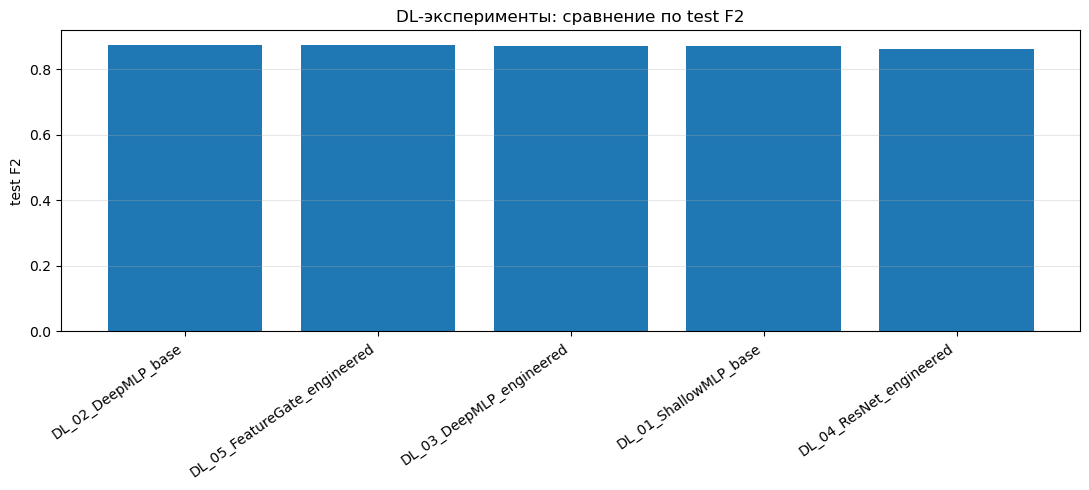

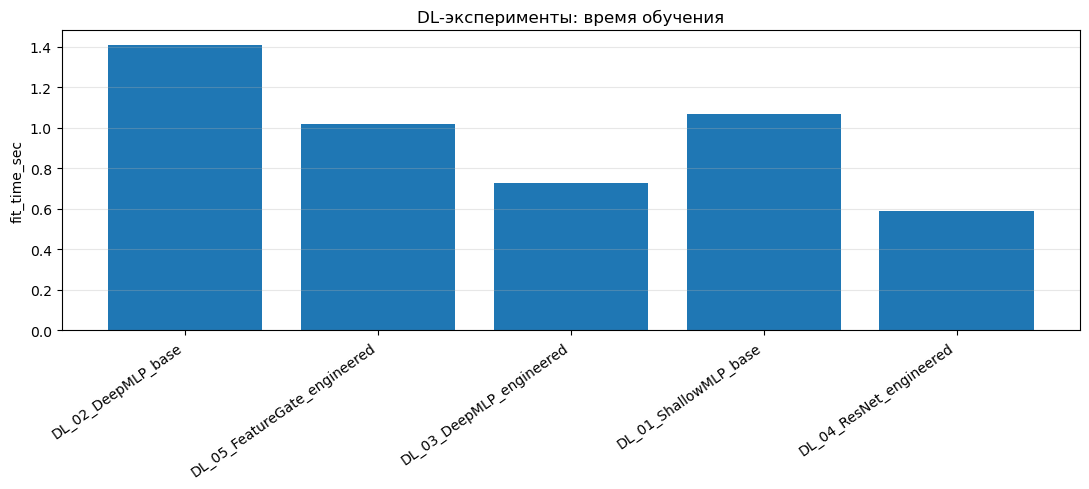

In [10]:
plt.figure(figsize=(11, 5))
plt.bar(dl_results["experiment"], dl_results["test_f2"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("test F2")
plt.title("DL-эксперименты: сравнение по test F2")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.bar(dl_results["experiment"], dl_results["fit_time_sec"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("fit_time_sec")
plt.title("DL-эксперименты: время обучения")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

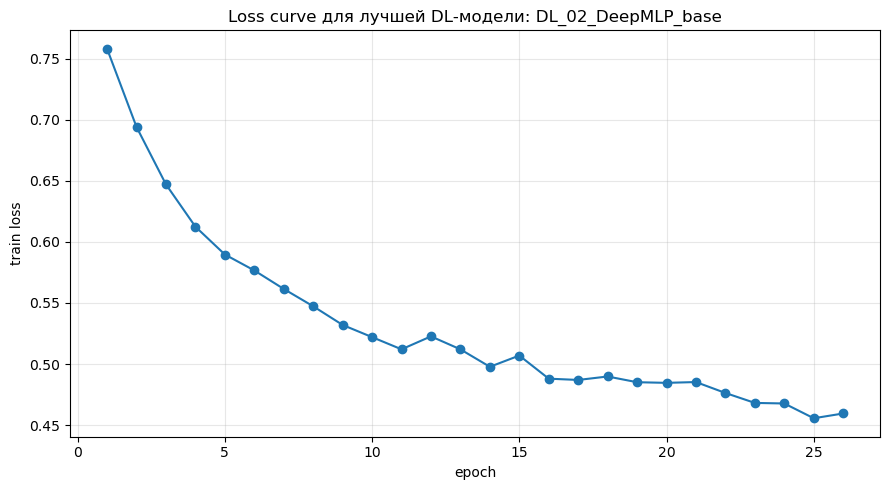

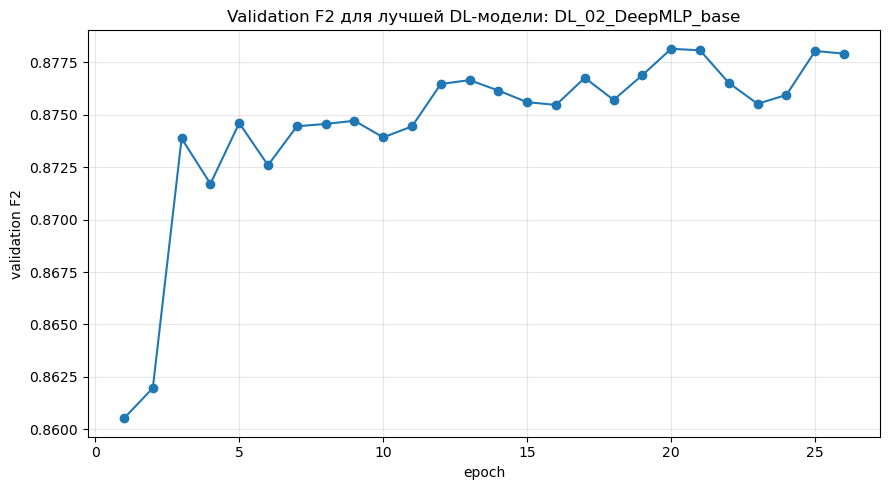

In [11]:
best_dl_exp = dl_results.iloc[0]["experiment"]
best_history = histories[best_dl_exp]

plt.figure(figsize=(9, 5))
plt.plot(best_history["epoch"], best_history["train_loss"], marker="o")
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.title(f"Loss curve для лучшей DL-модели: {best_dl_exp}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(best_history["epoch"], best_history["val_f2"], marker="o")
plt.xlabel("epoch")
plt.ylabel("validation F2")
plt.title(f"Validation F2 для лучшей DL-модели: {best_dl_exp}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Сравнение с ML-частью проекта

In [12]:
# Значения взяты из приложенного ноутбука Nonlinear_models_target_patology.ipynb.

ml_reference = pd.DataFrame([
    {
        "approach_group": "baseline",
        "experiment": "LogReg_base",
        "model": "LogisticRegression",
        "feature_set": "base",
        "val_f2": 0.8758,
        "test_f2": 0.8688,
        "test_recall": 0.9732,
        "fit_time_sec": 5.66,
        "comment": "baseline из ML-ноутбука",
    },
    {
        "approach_group": "ML",
        "experiment": "RandomForest_engineered",
        "model": "RandomForest",
        "feature_set": "engineered",
        "val_f2": 0.8859,
        "test_f2": 0.8772,
        "test_recall": 0.9806,
        "fit_time_sec": 69.58,
        "comment": "сильная ML-модель, но медленнее",
    },
    {
        "approach_group": "ML",
        "experiment": "CatBoost_engineered",
        "model": "CatBoost",
        "feature_set": "engineered",
        "val_f2": 0.8853,
        "test_f2": 0.8789,
        "test_recall": 0.9611,
        "fit_time_sec": 17.58,
        "comment": "бустинг на деревьях",
    },
    {
        "approach_group": "ML",
        "experiment": "XGBoost_base",
        "model": "XGBoost",
        "feature_set": "base",
        "val_f2": 0.8864,
        "test_f2": 0.8825,
        "test_recall": 0.9843,
        "fit_time_sec": 10.19,
        "comment": "лучшее ML-решение из прошлого чекпойнта",
    },
])

best_dl = dl_results.iloc[0].to_dict()
dl_reference = pd.DataFrame([{
    "approach_group": "DL",
    "experiment": best_dl["experiment"],
    "model": best_dl["architecture"],
    "feature_set": best_dl["feature_set"],
    "val_f2": best_dl["val_f2"],
    "test_f2": best_dl["test_f2"],
    "test_recall": best_dl["test_recall"],
    "fit_time_sec": best_dl["fit_time_sec"],
    "comment": "лучшее DL-решение из этого ноутбука",
}])

overall_comparison = pd.concat([ml_reference, dl_reference], ignore_index=True)
overall_comparison = overall_comparison.sort_values("test_f2", ascending=False).reset_index(drop=True)

display(overall_comparison)

,approach_group,experiment,model,feature_set,val_f2,test_f2,test_recall,fit_time_sec,comment
0,ML,XGBoost_base,XGBoost,base,0.8864,0.8825,0.9843,10.19,лучшее ML-решение из прошлого чекпойнта
1,ML,CatBoost_engineered,CatBoost,engineered,0.8853,0.8789,0.9611,17.58,бустинг на деревьях
2,ML,RandomForest_engineered,RandomForest,engineered,0.8859,0.8772,0.9806,69.58,"сильная ML-модель, но медленнее"
3,DL,DL_02_DeepMLP_base,Deep MLP: 39 -> 96 -> 48 -> 24 -> 1 + BN + Dro...,base,0.8782,0.8745,0.9621,1.41,лучшее DL-решение из этого ноутбука
4,baseline,LogReg_base,LogisticRegression,base,0.8758,0.8688,0.9732,5.66,baseline из ML-ноутбука


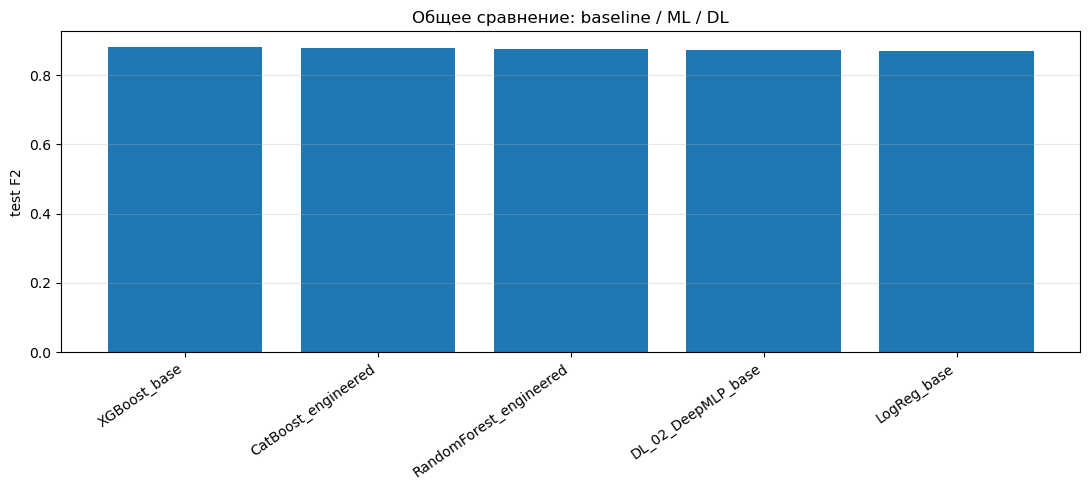

In [13]:
plt.figure(figsize=(11, 5))
plt.bar(overall_comparison["experiment"], overall_comparison["test_f2"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("test F2")
plt.title("Общее сравнение: baseline / ML / DL")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Выводы

### Лучшее DL-решение

Лучшей DL-моделью стала **Deep MLP на базовых признаках**: полносвязная сеть с тремя скрытыми слоями, BatchNorm и Dropout. Она лучше простой MLP, потому что у нее больше емкость для нелинейных взаимодействий между признаками, а BatchNorm и Dropout стабилизируют обучение и уменьшают переобучение.

### Почему разные DL-архитектуры сработали по-разному

1. **Shallow MLP** дает высокий recall, но хуже precision/F2. После подбора низкого threshold модель относит больше объектов к патологии: пропускает мало патологий, но дает больше ложных срабатываний.
2. **Deep MLP + BatchNorm + Dropout** дает лучший баланс recall/precision среди DL-моделей. Для табличных признаков ЭКГ этого уровня сложности оказалось достаточно.
3. **Engineered-признаки не дали устойчивого выигрыша для DL.** Агрегаты частично дублируют информацию исходных признаков. Нейросеть уже может собрать часть нелинейных комбинаций самостоятельно, а дополнительные признаки немного увеличивают шум и размерность.
4. **Residual MLP не улучшила результат.** На небольшой табличной выборке более сложная residual-структура не раскрылась: дополнительная глубина не дала устойчивого прироста.
5. **Feature-gated MLP** показала близкий к лучшему результат. Gate-механизм помогает пере-взвешивать признаки, но в этой задаче он не превзошел обычную Deep MLP.

### Почему ML оказался лучше DL

Лучшее ML-решение из предыдущего чекпойнта — **XGBoost_base** — осталось сильнее лучшей DL-модели по test F2 и recall. Это ожидаемо для текущей постановки:

- данные уже представлены как компактная табличная матрица признаков, а не как сырые ECG-сигналы;
- размер выборки около 10 тысяч строк, что для нейросетей не очень много;
- бустинг на деревьях хорошо работает с табличными данными, пороговыми зависимостями и нелинейными взаимодействиями признаков;
- DL-моделям обычно нужен либо больший объем данных, либо более богатое входное представление, например исходные временные ряды ЭКГ.

### Итог

Для текущего табличного датасета наиболее логичное итоговое решение Data Science-части — **XGBoost_base** из ML-части проекта. DL-подходы протестированы и дают качество, близкое к baseline/ML, но не улучшают лучшее решение. Если продолжать DL-направление, следующий шаг — работать не только с агрегированными табличными признаками, а с исходными ECG-сигналами и пробовать 1D-CNN или Transformer-like архитектуры для временных рядов.

In [14]:
dl_results.to_csv("dl_results_ecg_patology.csv", index=False)
overall_comparison.to_csv("overall_model_comparison_ecg_patology.csv", index=False)

print("Saved: dl_results_ecg_patology.csv")
print("Saved: overall_model_comparison_ecg_patology.csv")

Saved: dl_results_ecg_patology.csv
Saved: overall_model_comparison_ecg_patology.csv
